---
**Title:** Sequence Parallelism (SP)

**Category:** sequence-parallelism

**Difficulty:** Intermediate

**Estimated Time:** 40 min

---

## Overview

**Tensor Parallelism (TP)** splits weight matrices across GPUs — but what about LayerNorm and Dropout? These operations still keep **full activations** on every GPU, wasting memory.

**Sequence Parallelism (SP)** fixes this by splitting the **sequence dimension** for these non-TP regions, reducing activation memory proportionally to the number of GPUs.

This notebook builds up the idea step by step:

1. Why TP alone wastes activation memory
2. The **ReduceScatter** collective — inverse of AllGather
3. SP regions: splitting LayerNorm & Dropout across GPUs
4. How SP and TP couple together in a Transformer layer
5. Quantitative memory savings

### Prerequisites
- [02-tensor-parallelism/](02-tensor-parallelism.ipynb) — Column-Parallel, Row-Parallel, conjugate pair, AllReduce
- Basic understanding of LayerNorm and Dropout

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from mp_tutorial.viz import show_matrix, show_matrices_row, GPU_COLORS
from mp_tutorial.distributed import (
    simulate_allreduce, simulate_allgather, simulate_reduce_scatter, check_gpu_env
)
from mp_tutorial.formatting import code_reference

check_gpu_env()
torch.manual_seed(42)

%matplotlib inline

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


---
## 1. The problem: TP wastes activation memory

Recall from the TP notebook: in a Transformer layer, the MLP and Self-Attention blocks are parallelized with TP — each GPU holds only a **slice** of the weight matrices.

But a Transformer layer also has **LayerNorm** and **Dropout**. These operate on the full hidden dimension and don't involve weight splitting. Under TP alone, every GPU keeps a **full copy** of the activations for these operations.

**Activation memory** is the memory used to store intermediate results during the forward pass — needed later for backpropagation. For large models with long sequences, this can dominate GPU memory.

Let's visualize what each GPU stores:

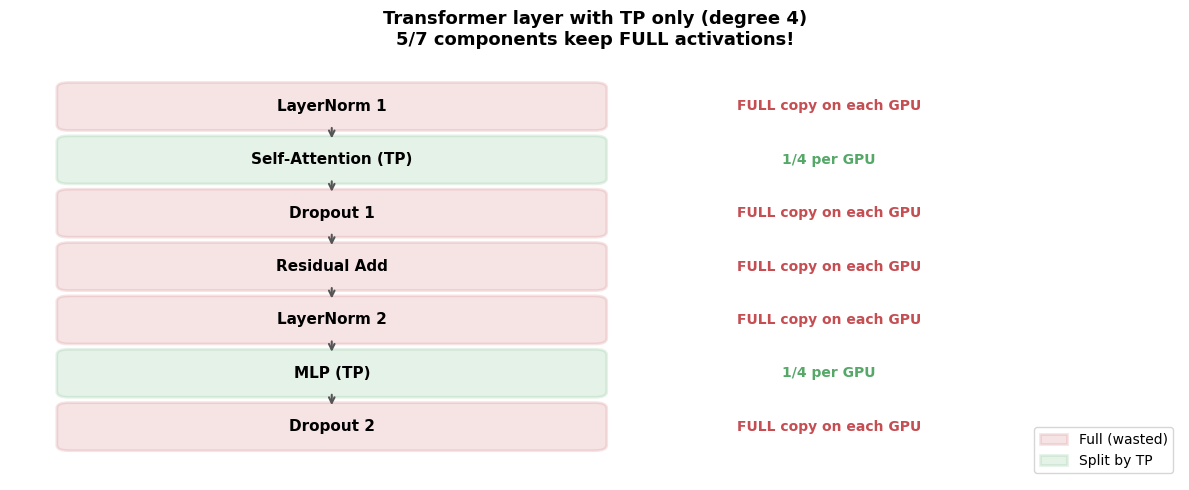

5 out of 7 components keep FULL activation copies — that's a lot of wasted memory!


In [2]:
def draw_tp_activation_waste(num_gpus=4):
    """Show which activations are replicated vs partitioned under TP alone."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis("off")

    # Components of a Transformer layer
    components = [
        # (y, label, tp_status, color)
        (7.0, "LayerNorm 1",        "FULL copy on each GPU",  "#C44E52"),
        (6.0, "Self-Attention (TP)", f"1/{num_gpus} per GPU",  "#55A868"),
        (5.0, "Dropout 1",          "FULL copy on each GPU",  "#C44E52"),
        (4.0, "Residual Add",       "FULL copy on each GPU",  "#C44E52"),
        (3.0, "LayerNorm 2",        "FULL copy on each GPU",  "#C44E52"),
        (2.0, "MLP (TP)",           f"1/{num_gpus} per GPU",  "#55A868"),
        (1.0, "Dropout 2",          "FULL copy on each GPU",  "#C44E52"),
    ]

    num_full = sum(1 for _, _, s, _ in components if "FULL" in s)
    num_split = sum(1 for _, _, s, _ in components if "1/" in s)

    for y, label, status, color in components:
        box = mpatches.FancyBboxPatch(
            (0.5, y - 0.35), 4.5, 0.7,
            boxstyle="round,pad=0.1", facecolor=color, alpha=0.15,
            edgecolor=color, linewidth=2
        )
        ax.add_patch(box)
        ax.text(2.75, y, label, ha="center", va="center",
                fontsize=11, fontweight="bold")
        ax.text(7, y, status, ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")

    # Arrows
    for i in range(len(components) - 1):
        y1 = components[i][0] - 0.35
        y2 = components[i + 1][0] + 0.35
        ax.annotate("", xy=(2.75, y2), xytext=(2.75, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    ax.set_title(
        f"Transformer layer with TP only (degree {num_gpus})\n"
        f"{num_full}/{num_full + num_split} components keep FULL activations!",
        fontsize=13, fontweight="bold"
    )

    # Legend
    full_patch = mpatches.Patch(facecolor="#C44E52", alpha=0.15, edgecolor="#C44E52",
                                linewidth=2, label="Full (wasted)")
    split_patch = mpatches.Patch(facecolor="#55A868", alpha=0.15, edgecolor="#55A868",
                                 linewidth=2, label="Split by TP")
    ax.legend(handles=[full_patch, split_patch], loc="lower right", fontsize=10)

    fig.tight_layout()
    return fig

fig = draw_tp_activation_waste()
plt.show()

print("5 out of 7 components keep FULL activation copies — that's a lot of wasted memory!")

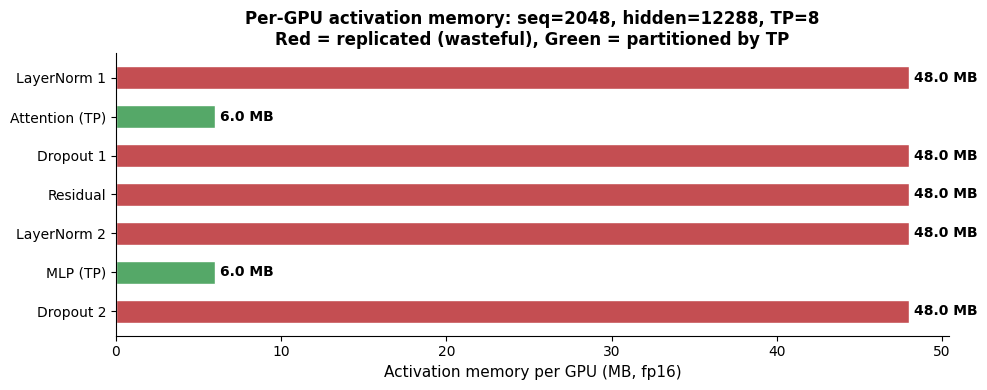

Replicated activations: 240.0 MB per GPU
Partitioned by TP:      12.0 MB per GPU
Ratio: 95% of activation memory is wasted duplication!


In [3]:
# Concrete memory example: a GPT-3 scale layer
seq_len = 2048
hidden = 12288
num_gpus = 8
bytes_per_elem = 2  # fp16

# Activation shape for each component: (seq_len, hidden) per sample
act_size = seq_len * hidden * bytes_per_elem  # bytes per activation tensor

components = {
    "LayerNorm 1":  act_size,
    "Attention (TP)": act_size // num_gpus,  # partitioned
    "Dropout 1":    act_size,
    "Residual":     act_size,
    "LayerNorm 2":  act_size,
    "MLP (TP)":     act_size // num_gpus,  # partitioned
    "Dropout 2":    act_size,
}

# Visualize as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))
names = list(components.keys())
sizes_mb = [v / 1024**2 for v in components.values()]
colors = ["#C44E52" if "TP" not in n else "#55A868" for n in names]

bars = ax.barh(names, sizes_mb, color=colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, sizes_mb):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} MB", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Activation memory per GPU (MB, fp16)", fontsize=11)
ax.set_title(f"Per-GPU activation memory: seq={seq_len}, hidden={hidden}, TP={num_gpus}\n"
             f"Red = replicated (wasteful), Green = partitioned by TP",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

full_total = sum(v for n, v in components.items() if "TP" not in n) / 1024**2
split_total = sum(v for n, v in components.items() if "TP" in n) / 1024**2
print(f"Replicated activations: {full_total:.1f} MB per GPU")
print(f"Partitioned by TP:      {split_total:.1f} MB per GPU")
print(f"Ratio: {full_total / (full_total + split_total):.0%} of activation memory is wasted duplication!")

**The idea:** Since LayerNorm and Dropout operate **independently on each token** (each row of the activation tensor), we can split along the **sequence dimension** — give each GPU a different subset of tokens. This is **Sequence Parallelism**.

---
## 2. ReduceScatter: the missing piece

To make SP work, we need a new collective operation: **ReduceScatter**.

Recall from the TP notebook:
- **AllReduce** = sum all GPUs' tensors, every GPU gets the full result
- **AllGather** = concatenate all GPUs' tensors, every GPU gets the full result

**ReduceScatter** is the inverse of AllGather:
1. **Reduce** — sum all GPUs' tensors element-wise (like AllReduce)
2. **Scatter** — split the result into chunks, GPU *i* gets chunk *i*

The key insight: **AllReduce = ReduceScatter + AllGather** (same total communication volume, but now each GPU only holds 1/N of the result after ReduceScatter).

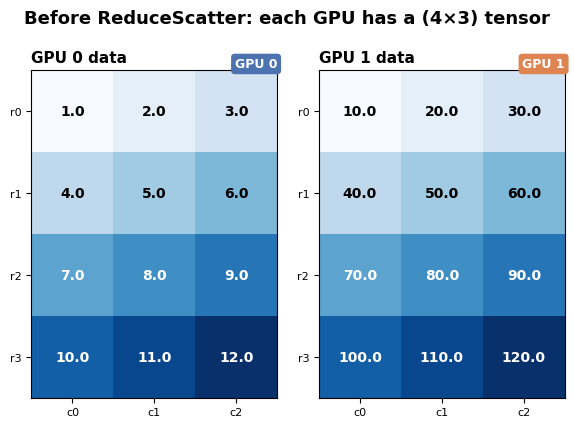

In [4]:
# Let's see ReduceScatter in action with small tensors
# 2 GPUs, each has a (4, 3) tensor
torch.manual_seed(7)
gpu0_data = torch.tensor([[1., 2., 3.],
                           [4., 5., 6.],
                           [7., 8., 9.],
                           [10., 11., 12.]])

gpu1_data = torch.tensor([[10., 20., 30.],
                           [40., 50., 60.],
                           [70., 80., 90.],
                           [100., 110., 120.]])

fig = show_matrices_row(
    [gpu0_data, gpu1_data],
    titles=["GPU 0 data", "GPU 1 data"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="Before ReduceScatter: each GPU has a (4×3) tensor",
    cmap="Blues"
)
plt.show()

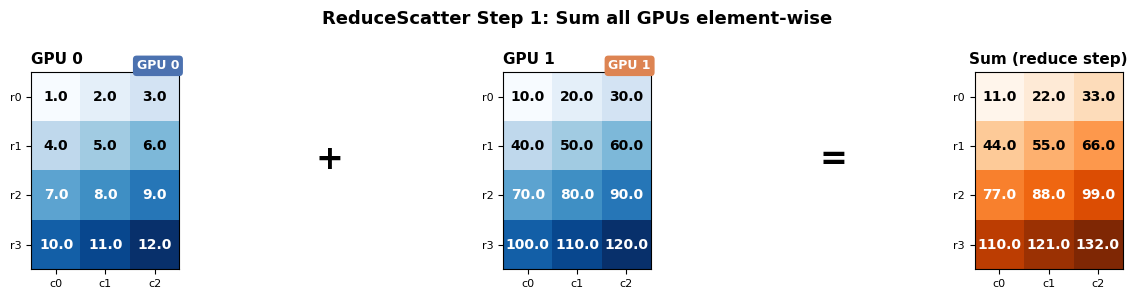

In [5]:
# Step 1: Reduce (sum) → Step 2: Scatter (split)
reduced_sum = gpu0_data + gpu1_data  # element-wise sum

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
show_matrix(gpu0_data, ax=axes[0], title="GPU 0", gpu_label="GPU 0", cmap="Blues")
show_matrix(gpu1_data, ax=axes[1], title="GPU 1", gpu_label="GPU 1", cmap="Blues")
show_matrix(reduced_sum, ax=axes[2], title="Sum (reduce step)", cmap="Oranges")
fig.text(0.345, 0.45, "+", fontsize=24, fontweight="bold", ha="center")
fig.text(0.66, 0.45, "=", fontsize=24, fontweight="bold", ha="center")
fig.suptitle("ReduceScatter Step 1: Sum all GPUs element-wise",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

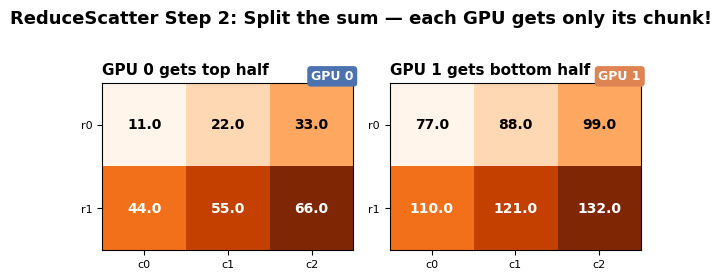

Before: each GPU had shape torch.Size([4, 3])
After:  each GPU has shape torch.Size([2, 3]) — half the memory!

ReduceScatter = Reduce (sum) + Scatter (split along dim 0)


In [6]:
# Step 2: Scatter — split the sum, GPU i gets chunk i
results = simulate_reduce_scatter([gpu0_data, gpu1_data])

fig = show_matrices_row(
    results,
    titles=["GPU 0 gets top half", "GPU 1 gets bottom half"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="ReduceScatter Step 2: Split the sum — each GPU gets only its chunk!",
    cmap="Oranges"
)
plt.show()

print(f"Before: each GPU had shape {gpu0_data.shape}")
print(f"After:  each GPU has shape {results[0].shape} — half the memory!")
print()
print("ReduceScatter = Reduce (sum) + Scatter (split along dim 0)")

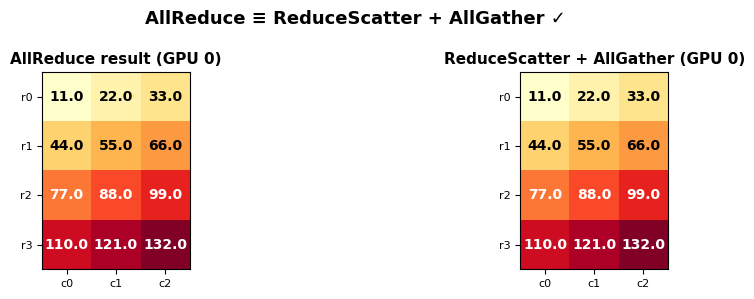

✓ Same result! But ReduceScatter alone leaves each GPU with 1/N of the data.


In [7]:
# Now let's show that AllReduce = ReduceScatter + AllGather
# First, AllReduce directly:
allreduced = simulate_allreduce([gpu0_data, gpu1_data])

# Second, ReduceScatter then AllGather:
scattered = simulate_reduce_scatter([gpu0_data, gpu1_data])
gathered = simulate_allgather(scattered)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
show_matrix(allreduced[0], ax=axes[0], title="AllReduce result (GPU 0)")
show_matrix(gathered[0],   ax=axes[1], title="ReduceScatter + AllGather (GPU 0)")
fig.suptitle("AllReduce ≡ ReduceScatter + AllGather ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(allreduced[0], gathered[0])
print("✓ Same result! But ReduceScatter alone leaves each GPU with 1/N of the data.")

### Communication comparison

| Operation | Each GPU starts with | Each GPU ends with | Communication volume |
|-----------|---------------------|-------------------|---------------------|
| **AllReduce** | (S, H) | **(S, H)** — full | 2×S×H per GPU |
| **ReduceScatter** | (S, H) | **(S/N, H)** — chunk | S×H per GPU |
| **AllGather** | (S/N, H) | **(S, H)** — full | S×H per GPU |
| **ReduceScatter + AllGather** | (S, H) | **(S, H)** — full | 2×S×H per GPU |

Same total communication, but ReduceScatter lets us **stay partitioned** for the SP region!

---
## 3. SP region: splitting LayerNorm and Dropout

LayerNorm and Dropout both operate **independently on each token** (i.e., each row of the `(seq_len, hidden)` activation tensor). This means we can safely split along the sequence dimension — each GPU processes a subset of tokens.

**LayerNorm** normalizes each token's hidden vector to have zero mean and unit variance. Since each token is normalized independently, splitting by sequence is safe.

**Dropout** randomly zeroes elements during training. Again, it's applied independently per element, so splitting by sequence is safe.

Let's demonstrate with a small example:

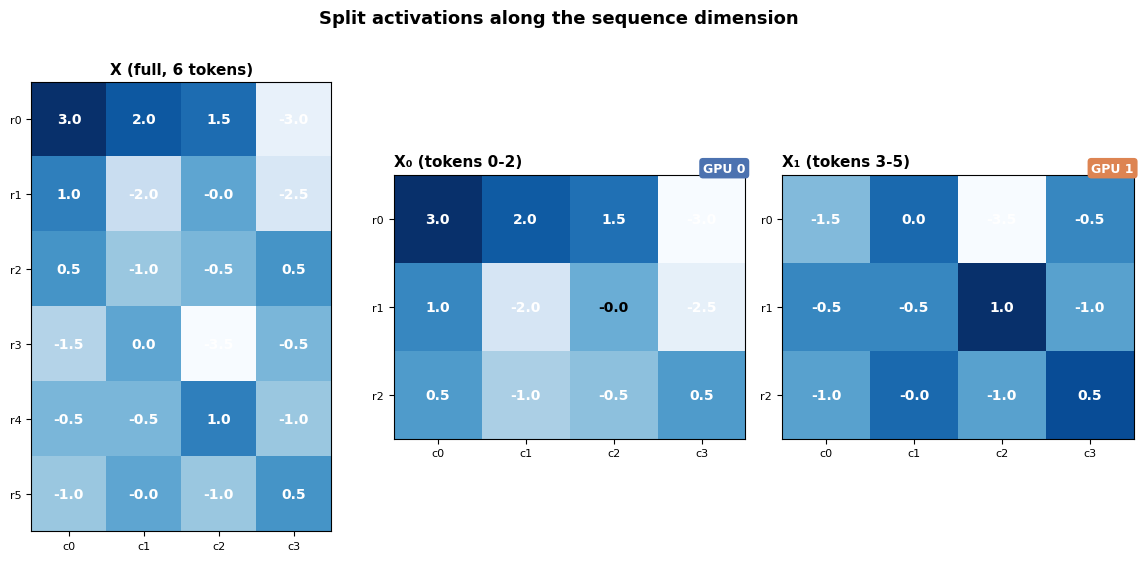

In [8]:
# Full activation: 6 tokens, hidden=4, on 2 GPUs
torch.manual_seed(42)
seq_len, hidden_dim, num_gpus = 6, 4, 2
X = (torch.randn(seq_len, hidden_dim) * 3).round() / 2

layer_norm = nn.LayerNorm(hidden_dim)

# Reference: LayerNorm on the full tensor
Y_ref = layer_norm(X)

# SP: split sequence, LayerNorm independently, check result
X_chunks = X.chunk(num_gpus, dim=0)  # split along sequence dim

fig = show_matrices_row(
    [X] + list(X_chunks),
    titles=["X (full, 6 tokens)", "X₀ (tokens 0-2)", "X₁ (tokens 3-5)"],
    gpu_labels=[None, "GPU 0", "GPU 1"],
    suptitle="Split activations along the sequence dimension",
    cmap="Blues"
)
plt.show()

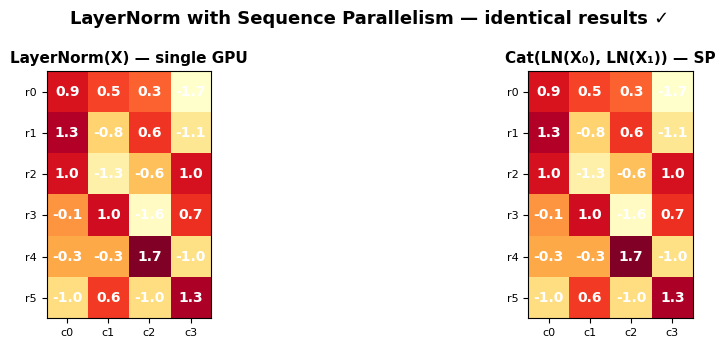

✓ SP LayerNorm matches! Each GPU processes its tokens independently.


In [9]:
# Each GPU applies LayerNorm to its chunk — no communication needed!
Y_chunks = [layer_norm(chunk) for chunk in X_chunks]
Y_sp = torch.cat(Y_chunks, dim=0)  # reassemble for comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
show_matrix(Y_ref, ax=axes[0], title="LayerNorm(X) — single GPU")
show_matrix(Y_sp,  ax=axes[1], title="Cat(LN(X₀), LN(X₁)) — SP")
fig.suptitle("LayerNorm with Sequence Parallelism — identical results ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_ref, Y_sp, atol=1e-6)
print("✓ SP LayerNorm matches! Each GPU processes its tokens independently.")

**Key insight:** In SP regions (LayerNorm, Dropout, residual add), each GPU holds `(S/N, H)` instead of `(S, H)` — activations are split by sequence, reducing memory by N×.

But there's a catch: TP regions (attention, MLP) need the **full sequence** because column-parallel takes full input. So we need to **gather** before TP and **scatter** after TP.

---
## 4. SP + TP coupling: the full picture

In TP alone, each linear block ends with an **AllReduce** to sum partial results. SP replaces this AllReduce with:

- **ReduceScatter** after TP (sum partials → each GPU gets its sequence chunk)
- **AllGather** before TP (gather all chunks → each GPU gets full sequence)

This swaps the old pattern:
```
[TP block] → AllReduce → LayerNorm (full) → [TP block] → AllReduce → ...
```
For the new SP+TP pattern:
```
[TP block] → ReduceScatter → LayerNorm (split) → AllGather → [TP block] → ReduceScatter → ...
```

Same communication volume, but now LayerNorm/Dropout operate on `(S/N, H)` instead of `(S, H)`!

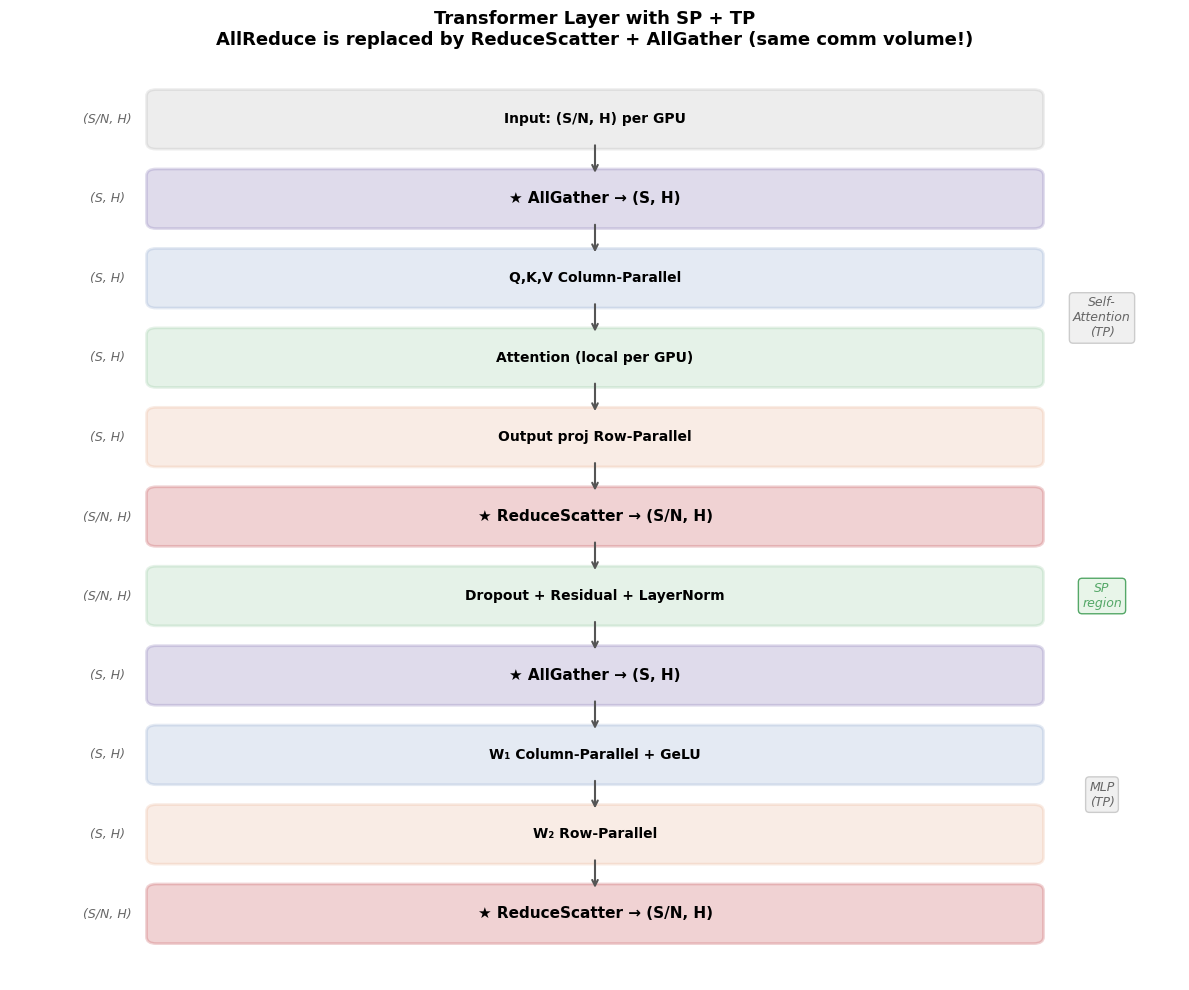

In [10]:
def draw_sp_tp_transformer():
    """Visualize a full Transformer layer with SP+TP coupling."""
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 14)
    ax.axis("off")

    # Blocks: (x, y, w, h, text, color, region_label)
    blocks = [
        (6, 13.0, 9, 0.7, "Input: (S/N, H) per GPU",         "#888",     "SP"),
        (6, 11.8, 9, 0.7, "★ AllGather → (S, H)",             "#8172B3",  "comm"),
        (6, 10.6, 9, 0.7, "Q,K,V Column-Parallel",            GPU_COLORS[0], "TP"),
        (6,  9.4, 9, 0.7, "Attention (local per GPU)",         GPU_COLORS[2], "TP"),
        (6,  8.2, 9, 0.7, "Output proj Row-Parallel",          GPU_COLORS[1], "TP"),
        (6,  7.0, 9, 0.7, "★ ReduceScatter → (S/N, H)",       "#C44E52",  "comm"),
        (6,  5.8, 9, 0.7, "Dropout + Residual + LayerNorm",    "#55A868",  "SP"),
        (6,  4.6, 9, 0.7, "★ AllGather → (S, H)",              "#8172B3",  "comm"),
        (6,  3.4, 9, 0.7, "W₁ Column-Parallel + GeLU",        GPU_COLORS[0], "TP"),
        (6,  2.2, 9, 0.7, "W₂ Row-Parallel",                  GPU_COLORS[1], "TP"),
        (6,  1.0, 9, 0.7, "★ ReduceScatter → (S/N, H)",       "#C44E52",  "comm"),
    ]

    region_colors = {"SP": "#55A868", "TP": "#4C72B0", "comm": "#C44E52"}

    for x, y, w, h, text, color, region in blocks:
        alpha = 0.25 if "★" in text else 0.15
        box = mpatches.FancyBboxPatch(
            (x - w/2, y - h/2), w, h,
            boxstyle="round,pad=0.1", facecolor=color, alpha=alpha,
            edgecolor=color, linewidth=2
        )
        ax.add_patch(box)
        fs = 11 if "★" in text else 10
        ax.text(x, y, text, ha="center", va="center", fontsize=fs, fontweight="bold")

    # Region labels on the right
    # Self-Attention block
    ax.text(11.2, 10.0, "Self-\nAttention\n(TP)", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#666",
            bbox=dict(boxstyle="round", fc="#f0f0f0", ec="#ccc"))
    # MLP block
    ax.text(11.2, 2.8, "MLP\n(TP)", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#666",
            bbox=dict(boxstyle="round", fc="#f0f0f0", ec="#ccc"))
    # SP region
    ax.text(11.2, 5.8, "SP\nregion", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#55A868",
            bbox=dict(boxstyle="round", fc="#e8f5e9", ec="#55A868"))

    # Arrows between blocks
    for i in range(len(blocks) - 1):
        y1 = blocks[i][1] - blocks[i][3]/2
        y2 = blocks[i + 1][1] + blocks[i + 1][3]/2
        ax.annotate("", xy=(6, y2), xytext=(6, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    # Activation shape annotations on the left
    shapes = [
        (13.0, "(S/N, H)"), (11.8, "(S, H)"), (10.6, "(S, H)"),
        (9.4, "(S, H)"), (8.2, "(S, H)"), (7.0, "(S/N, H)"),
        (5.8, "(S/N, H)"), (4.6, "(S, H)"), (3.4, "(S, H)"),
        (2.2, "(S, H)"), (1.0, "(S/N, H)")
    ]
    for y, shape in shapes:
        ax.text(1.0, y, shape, ha="center", va="center", fontsize=9,
                color="#666", fontstyle="italic")

    ax.set_title(
        "Transformer Layer with SP + TP\n"
        "AllReduce is replaced by ReduceScatter + AllGather (same comm volume!)",
        fontsize=13, fontweight="bold"
    )
    fig.tight_layout()
    return fig

fig = draw_sp_tp_transformer()
plt.show()

In [11]:
# End-to-end simulation: SP+TP MLP block
# 2 GPUs, seq=6, hidden=4, intermediate=6
torch.manual_seed(7)
num_gpus = 2
seq_len, hidden_dim, inter_dim = 6, 4, 6

X = (torch.randn(seq_len, hidden_dim) * 2).round() / 2
W1 = (torch.randn(hidden_dim, inter_dim) * 2).round() / 2
W2 = (torch.randn(inter_dim, hidden_dim) * 2).round() / 2
ln = nn.LayerNorm(hidden_dim)

# --- Reference: single-GPU ---
Y_ref = F.gelu(ln(X) @ W1) @ W2

# --- SP+TP simulation ---
# Step 1: Input is sequence-partitioned (SP region)
X_sp = X.chunk(num_gpus, dim=0)  # (S/N, H) per GPU
print("Step 1 — SP input:  each GPU has", X_sp[0].shape)

# Step 2: LayerNorm on each chunk (SP — no communication)
X_ln = [ln(chunk) for chunk in X_sp]
print("Step 2 — LayerNorm: each GPU has", X_ln[0].shape, "(no comm)")

# Step 3: AllGather to get full sequence for TP
X_full = simulate_allgather(X_ln)
print("Step 3 — AllGather: each GPU has", X_full[0].shape)

# Step 4: Column-parallel W1 + GeLU
W1_chunks = W1.chunk(num_gpus, dim=1)
H_parts = [F.gelu(X_full[g] @ W1_chunks[g]) for g in range(num_gpus)]
print("Step 4 — ColPar:   each GPU has", H_parts[0].shape)

# Step 5: Row-parallel W2
W2_chunks = W2.chunk(num_gpus, dim=0)
Y_parts = [H_parts[g] @ W2_chunks[g] for g in range(num_gpus)]
print("Step 5 — RowPar:   each GPU has", Y_parts[0].shape, "(partial sums)")

# Step 6: ReduceScatter (instead of AllReduce!)
Y_sp = simulate_reduce_scatter(Y_parts)
print("Step 6 — ReduceScatter: each GPU has", Y_sp[0].shape, "← back to SP!")

Step 1 — SP input:  each GPU has torch.Size([3, 4])
Step 2 — LayerNorm: each GPU has torch.Size([3, 4]) (no comm)
Step 3 — AllGather: each GPU has torch.Size([6, 4])
Step 4 — ColPar:   each GPU has torch.Size([6, 3])
Step 5 — RowPar:   each GPU has torch.Size([6, 4]) (partial sums)
Step 6 — ReduceScatter: each GPU has torch.Size([3, 4]) ← back to SP!


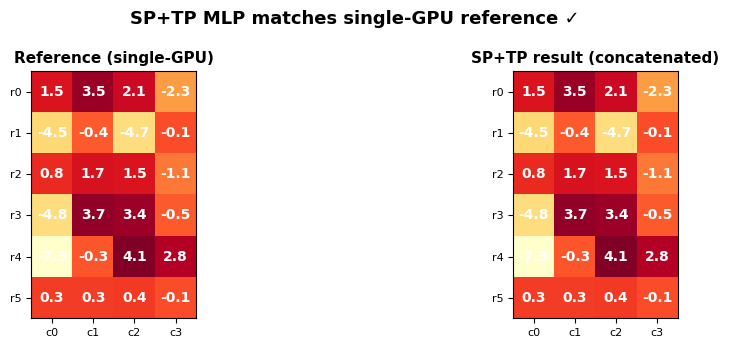

✓ SP+TP result matches! Same math, less memory per GPU.


In [12]:
# Verify: concatenate SP chunks and compare with reference
Y_combined = torch.cat(Y_sp, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
show_matrix(Y_ref,      ax=axes[0], title="Reference (single-GPU)")
show_matrix(Y_combined, ax=axes[1], title="SP+TP result (concatenated)")
fig.suptitle("SP+TP MLP matches single-GPU reference ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_combined, Y_ref, atol=1e-5)
print("✓ SP+TP result matches! Same math, less memory per GPU.")

### TP-only vs SP+TP: side-by-side comparison

| | TP only | SP + TP |
|---|---|---|
| **LayerNorm/Dropout** | Full `(S, H)` on each GPU | Split `(S/N, H)` per GPU |
| **Attention/MLP** | Partitioned by TP | Same — partitioned by TP |
| **Communication** | 2 AllReduce per layer | 2 AllGather + 2 ReduceScatter |
| **Comm volume** | 2 × 2SH = **4SH** | 2 × SH + 2 × SH = **4SH** |
| **Activation memory** | Most at full `(S, H)` | SP regions at `(S/N, H)` |

**Same communication, less memory!**

---
## 5. Memory savings: before and after

Let's quantify the activation memory savings from SP. We'll use a GPT-3-scale model as our example.

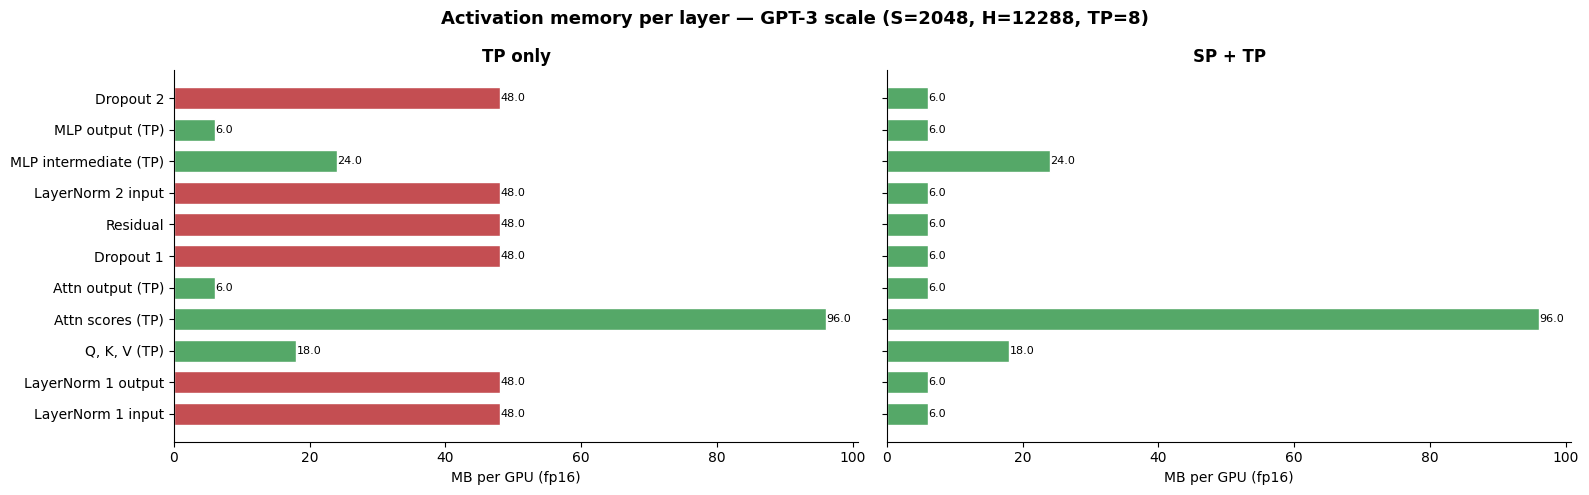

TP only:  438.0 MB per GPU per layer
SP + TP:  186.0 MB per GPU per layer
Savings:  58% reduction in activation memory!


In [13]:
def compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=False):
    """Compute per-GPU activation memory (in bytes, fp16) for one Transformer layer.

    Components and their activation shapes:
    - LayerNorm input: (S, H) — or (S/N, H) with SP
    - Q,K,V projections: already partitioned by TP → (S, H/N)
    - Attention scores: (num_heads/N, S, S) — partitioned by TP over heads
    - Attention output: (S, H/N)
    - MLP intermediate: (S, 4H/N) — column-parallel
    - Dropout masks: same shape as their inputs
    """
    N = tp_degree
    bpe = 2  # bytes per element (fp16)
    S = seq_len
    H = hidden

    # SP regions: full or partitioned
    sp_seq = S // N if use_sp else S

    # Activation sizes per component
    memory = {
        "LayerNorm 1 input":     sp_seq * H * bpe,
        "LayerNorm 1 output":    sp_seq * H * bpe,
        "Q, K, V (TP)":          3 * S * (H // N) * bpe,
        "Attn scores (TP)":      (num_heads // N) * S * S * bpe,
        "Attn output (TP)":      S * (H // N) * bpe,
        "Dropout 1":             sp_seq * H * bpe,
        "Residual":              sp_seq * H * bpe,
        "LayerNorm 2 input":     sp_seq * H * bpe,
        "MLP intermediate (TP)": S * (4 * H // N) * bpe,
        "MLP output (TP)":       S * (H // N) * bpe,
        "Dropout 2":             sp_seq * H * bpe,
    }
    return memory

# GPT-3 175B parameters
seq_len = 2048
hidden = 12288
num_heads = 96
tp_degree = 8

mem_tp_only = compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=False)
mem_sp_tp = compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=True)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, mem, title, color_scheme in [
    (axes[0], mem_tp_only, "TP only", {"SP": "#C44E52", "TP": "#55A868"}),
    (axes[1], mem_sp_tp,   "SP + TP", {"SP": "#55A868", "TP": "#55A868"}),
]:
    names = list(mem.keys())
    sizes_mb = [v / 1024**2 for v in mem.values()]
    colors = [color_scheme["TP"] if "(TP)" in n else color_scheme["SP"] for n in names]

    bars = ax.barh(names, sizes_mb, color=colors, edgecolor="white", height=0.7)
    for bar, val in zip(bars, sizes_mb):
        if val > 0.5:
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}", va="center", fontsize=8)

    ax.set_xlabel("MB per GPU (fp16)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(f"Activation memory per layer — GPT-3 scale (S={seq_len}, H={hidden}, TP={tp_degree})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

total_tp = sum(mem_tp_only.values()) / 1024**2
total_sp = sum(mem_sp_tp.values()) / 1024**2
print(f"TP only:  {total_tp:.1f} MB per GPU per layer")
print(f"SP + TP:  {total_sp:.1f} MB per GPU per layer")
print(f"Savings:  {(1 - total_sp / total_tp):.0%} reduction in activation memory!")

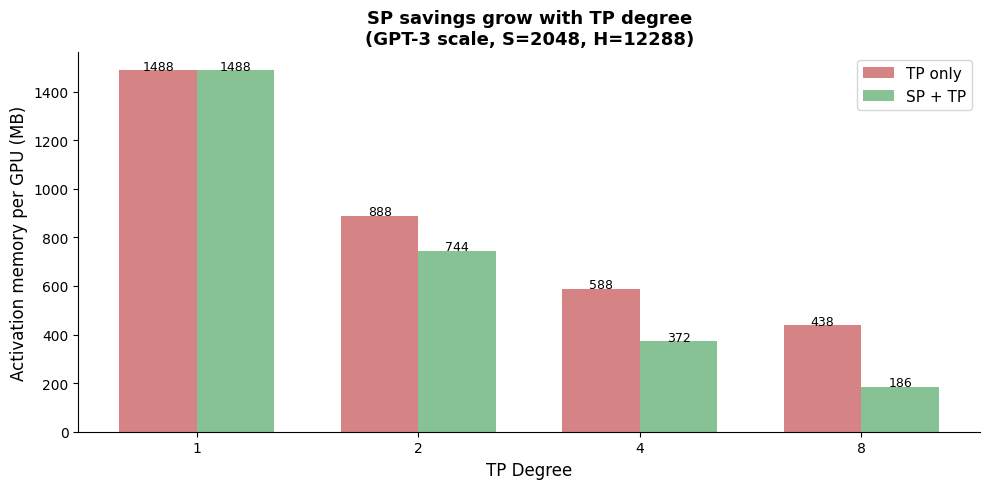

TP=1: 1488 MB → 1488 MB (0% saved)
TP=2: 888 MB → 744 MB (16% saved)
TP=4: 588 MB → 372 MB (37% saved)
TP=8: 438 MB → 186 MB (58% saved)


In [14]:
# How does the savings scale with TP degree?
tp_degrees = [1, 2, 4, 8]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tp_degrees))
width = 0.35

tp_totals = []
sp_totals = []
for tp in tp_degrees:
    mem_tp = compute_activation_memory(2048, 12288, 96, tp, use_sp=False)
    mem_sp = compute_activation_memory(2048, 12288, 96, tp, use_sp=True)
    tp_totals.append(sum(mem_tp.values()) / 1024**2)
    sp_totals.append(sum(mem_sp.values()) / 1024**2)

bars1 = ax.bar(x - width/2, tp_totals, width, label="TP only", color="#C44E52", alpha=0.7)
bars2 = ax.bar(x + width/2, sp_totals, width, label="SP + TP", color="#55A868", alpha=0.7)

for bar, val in zip(bars1, tp_totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=9)
for bar, val in zip(bars2, sp_totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=9)

ax.set_xlabel("TP Degree", fontsize=12)
ax.set_ylabel("Activation memory per GPU (MB)", fontsize=12)
ax.set_title("SP savings grow with TP degree\n(GPT-3 scale, S=2048, H=12288)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tp_degrees)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

for tp, tp_v, sp_v in zip(tp_degrees, tp_totals, sp_totals):
    print(f"TP={tp}: {tp_v:.0f} MB → {sp_v:.0f} MB ({(1 - sp_v/tp_v):.0%} saved)")

---
## 6. Application in LLMs

SP is **always used together with TP** in production systems — it's essentially free (same communication volume) and saves significant activation memory.

| Model | TP | SP | Notes |
|-------|----|----|-------|
| Megatron-LM v2+ | 8 | 8 | SP introduced in the Megatron v2 paper |
| LLaMA 2/3 | 8 | 8 | Uses Megatron-style SP+TP |
| PaLM | 8 | 8 | TPU equivalent of SP+TP |
| GPT-NeoX | 8 | 8 | SP enabled by default with TP |

SP is controlled by the same degree as TP — if you use TP=8, SP is also across those 8 GPUs. There is no separate "SP degree" knob.

---
## 7. GPU-Required: real multi-GPU SP+TP

> **GPU Required** — Run this cell on a multi-GPU machine (4+ GPUs recommended).

In [ ]:
# [GPU-REQUIRED]
# Real multi-GPU SP+TP: LayerNorm with SP, MLP with TP, connected by AllGather/ReduceScatter
# Run on a multi-GPU machine (4+ GPUs recommended)

import torch
import torch.distributed as dist
import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
import os

def sp_tp_mlp_worker(rank, world_size, X_shared, W1_shared, W2_shared, ln_weight, ln_bias, results):
    """Worker for one GPU in SP+TP MLP."""
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "29501"
    dist.init_process_group("nccl", rank=rank, world_size=world_size)

    device = torch.device(f"cuda:{rank}")
    seq_len = X_shared.shape[0]
    chunk_size = seq_len // world_size

    # SP: each GPU gets its sequence chunk
    X_local = X_shared[rank * chunk_size:(rank + 1) * chunk_size].to(device)

    # LayerNorm on local chunk (SP region — no communication)
    ln = nn.LayerNorm(X_shared.shape[1]).to(device)
    ln.weight.data.copy_(ln_weight.to(device))
    ln.bias.data.copy_(ln_bias.to(device))
    X_normed = ln(X_local)

    # AllGather to get full sequence for TP
    gathered = [torch.zeros_like(X_normed) for _ in range(world_size)]
    dist.all_gather(gathered, X_normed)
    X_full = torch.cat(gathered, dim=0)

    # Column-parallel W1 + GeLU
    inter_size = W1_shared.shape[1]
    chunk_cols = inter_size // world_size
    W1_local = W1_shared[:, rank * chunk_cols:(rank + 1) * chunk_cols].to(device)
    hidden = F.gelu(X_full @ W1_local)

    # Row-parallel W2
    W2_local = W2_shared[rank * chunk_cols:(rank + 1) * chunk_cols, :].to(device)
    output = hidden @ W2_local  # partial sum

    # ReduceScatter: sum partials and scatter along sequence dim
    output_chunk = torch.zeros(chunk_size, W2_shared.shape[1], device=device)
    dist.reduce_scatter_tensor(output_chunk, output)

    results[rank] = output_chunk.cpu()
    dist.destroy_process_group()

if torch.cuda.is_available() and torch.cuda.device_count() >= 4:
    world_size = 4
    seq_len, hidden_dim, inter_dim = 32, 64, 256

    torch.manual_seed(42)
    X = torch.randn(seq_len, hidden_dim)
    W1 = torch.randn(hidden_dim, inter_dim)
    W2 = torch.randn(inter_dim, hidden_dim)
    ln = nn.LayerNorm(hidden_dim)

    # Reference
    Y_ref = F.gelu(ln(X) @ W1) @ W2

    manager = mp.Manager()
    results = manager.dict()
    mp.spawn(sp_tp_mlp_worker,
             args=(world_size, X, W1, W2, ln.weight.data, ln.bias.data, results),
             nprocs=world_size)

    Y_sp_tp = torch.cat([results[r] for r in range(world_size)], dim=0)
    print(f"Max error: {(Y_sp_tp - Y_ref).abs().max().item():.2e}")
    print("✓ Real multi-GPU SP+TP matches reference!")
else:
    print("Skipping: requires 4 CUDA GPUs")

> **Advanced section — feel free to skip.** This section references Megatron-LM's internal implementation. It's included for completeness but is not needed to understand the core SP concepts above.

---
## 8. Megatron-LM Reference

Megatron-LM implements SP by replacing the TP communication primitives. The key change is in the custom autograd functions in `mappings.py`:

In [15]:
code_reference(
    code="""
# With sequence_parallel=True, the TP communication changes:
#
# TP only:
#   ColumnParallel input:  Identity fwd, AllReduce bwd
#   RowParallel output:    AllReduce fwd, Identity bwd
#
# SP + TP:
#   ColumnParallel input:  AllGather fwd, ReduceScatter bwd
#   RowParallel output:    ReduceScatter fwd, AllGather bwd

class _AllGatherFromSequenceParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_):
        # AllGather along sequence dim: (S/N, H) → (S, H)
        return _gather_along_first_dim(input_)

    @staticmethod
    def backward(ctx, grad_output):
        # ReduceScatter in backward: (S, H) → (S/N, H)
        return _reduce_scatter_along_first_dim(grad_output)

class _ReduceScatterToSequenceParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_):
        # ReduceScatter along sequence dim: (S, H) → (S/N, H)
        return _reduce_scatter_along_first_dim(input_)

    @staticmethod
    def backward(ctx, grad_output):
        # AllGather in backward: (S/N, H) → (S, H)
        return _gather_along_first_dim(grad_output)
""",
    source="Megatron-LM",
    filepath="megatron/core/tensor_parallel/mappings.py"
)

Notice the **conjugate pattern** in autograd:
- AllGather in forward ↔ ReduceScatter in backward
- ReduceScatter in forward ↔ AllGather in backward

This ensures correct gradient flow through the SP+TP boundary.

| Forward | Backward | Where used |
|---------|----------|------------|
| AllGather | ReduceScatter | Before ColumnParallel (SP → TP) |
| ReduceScatter | AllGather | After RowParallel (TP → SP) |

Key files in Megatron-LM:
- `megatron/core/tensor_parallel/mappings.py` — SP communication primitives
- `megatron/core/tensor_parallel/layers.py` — `ColumnParallelLinear`, `RowParallelLinear` with `sequence_parallel` flag
- `megatron/core/transformer/transformer_layer.py` — full Transformer layer wiring SP and TP together

---
## Summary & Further Reading

### Key Takeaways

1. TP alone leaves LayerNorm/Dropout with **full replicated activations** — wasting memory
2. **ReduceScatter** = reduce (sum) + scatter (split) — the inverse of AllGather
3. **AllReduce ≡ ReduceScatter + AllGather** — same communication volume
4. SP splits the **sequence dimension** for non-TP operations (LayerNorm, Dropout, residual)
5. SP replaces AllReduce with ReduceScatter + AllGather at TP boundaries — **same comm cost, less memory**
6. SP is always coupled with TP at the **same degree** (typically 8)
7. In Megatron-LM, SP is a flag on the existing TP layers — minimal code change

### Further Reading

- [Reducing Activation Recomputation in Large Transformer Models](https://arxiv.org/abs/2205.05198) — the Megatron SP paper
- [Megatron-LM: Training Multi-Billion Parameter Language Models Using Model Parallelism](https://arxiv.org/abs/1909.08053)
- [NVIDIA Megatron-Core](https://github.com/NVIDIA/Megatron-LM) — see `megatron/core/tensor_parallel/`
- Previous: [02-tensor-parallelism/](02-tensor-parallelism.ipynb) — TP fundamentals
- Next: [05-context-parallelism/](05-context-parallelism.ipynb) — splitting attention across GPUs for long sequences